In [1]:
import numpy as np
from scipy.special import erfc

np.random.seed(42)
Eb_N0_dB = np.arange(-3, 11)
num_bits = int(1e5)
min_errors = 100

simulated_ber = []
theoretical_ber = []

for snr_db in Eb_N0_dB:
    print(f"Simulating Eb/N0 = {snr_db} dB...")
    snr_linear = 10 ** (snr_db / 10)
    noise_std = np.sqrt(1 / (2 * snr_linear))
    total_errors, total_bits = 0, 0

    while total_errors < min_errors:
        bits = np.random.randint(0, 2, num_bits)
        signal = 2 * bits - 1
        noise = noise_std * np.random.randn(num_bits)
        received_signal = signal + noise
        decoded_bits = (received_signal >= 0).astype(int)
        total_errors += np.sum(bits != decoded_bits)
        total_bits += num_bits

    ber_sim = total_errors / total_bits
    simulated_ber.append(ber_sim)
    ber_theory = 0.5 * erfc(np.sqrt(snr_linear))
    theoretical_ber.append(ber_theory)
    print(f"  Simulated BER = {ber_sim:.2e}, Theoretical BER = {ber_theory:.2e}")

print("Simulation finished!")

Simulating Eb/N0 = -3 dB...
  Simulated BER = 1.58e-01, Theoretical BER = 1.58e-01
Simulating Eb/N0 = -2 dB...
  Simulated BER = 1.31e-01, Theoretical BER = 1.31e-01
Simulating Eb/N0 = -1 dB...
  Simulated BER = 1.05e-01, Theoretical BER = 1.04e-01
Simulating Eb/N0 = 0 dB...
  Simulated BER = 7.83e-02, Theoretical BER = 7.86e-02
Simulating Eb/N0 = 1 dB...
  Simulated BER = 5.62e-02, Theoretical BER = 5.63e-02
Simulating Eb/N0 = 2 dB...
  Simulated BER = 3.72e-02, Theoretical BER = 3.75e-02
Simulating Eb/N0 = 3 dB...
  Simulated BER = 2.29e-02, Theoretical BER = 2.29e-02
Simulating Eb/N0 = 4 dB...
  Simulated BER = 1.29e-02, Theoretical BER = 1.25e-02
Simulating Eb/N0 = 5 dB...
  Simulated BER = 6.46e-03, Theoretical BER = 5.95e-03
Simulating Eb/N0 = 6 dB...
  Simulated BER = 2.43e-03, Theoretical BER = 2.39e-03
Simulating Eb/N0 = 7 dB...
  Simulated BER = 7.50e-04, Theoretical BER = 7.73e-04
Simulating Eb/N0 = 8 dB...
  Simulated BER = 2.03e-04, Theoretical BER = 1.91e-04
Simulating Eb

In [2]:
import pandas as pd

df = pd.DataFrame({
    'Eb_N0_dB': Eb_N0_dB,
    'Simulated_BER': simulated_ber,
    'Theoretical_BER': theoretical_ber
})
df['Error_Ratio'] = df['Simulated_BER'] / df['Theoretical_BER']

print(df.head(10))
print(df.describe())
df.to_csv('data/bpsk_ber_results.csv', index=False)
print("Data saved to bpsk_ber_results.csv")

   Eb_N0_dB  Simulated_BER  Theoretical_BER  Error_Ratio
0        -3        0.15794         0.158368     0.997295
1        -2        0.13087         0.130644     1.001726
2        -1        0.10530         0.103759     1.014851
3         0        0.07834         0.078650     0.996064
4         1        0.05621         0.056282     0.998722
5         2        0.03717         0.037506     0.991038
6         3        0.02291         0.022878     1.001381
7         4        0.01288         0.012501     1.030333
8         5        0.00646         0.005954     1.085009
9         6        0.00243         0.002388     1.017464
       Eb_N0_dB  Simulated_BER  Theoretical_BER  Error_Ratio
count   14.0000      14.000000        14.000000    14.000000
mean     3.5000       0.043679         0.043567     1.013428
std      4.1833       0.053971         0.053940     0.039849
min     -3.0000       0.000004         0.000004     0.941660
25%      0.2500       0.001170         0.001177     0.996371
50%    

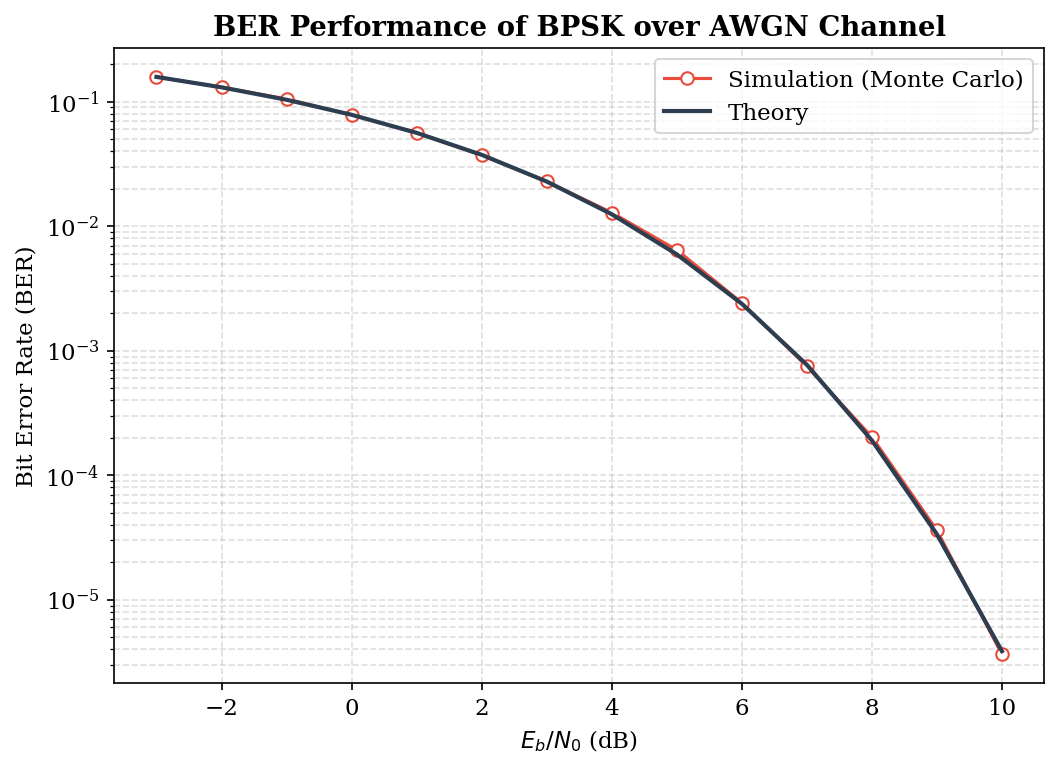

Figures saved!


In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.family': 'serif', 'font.size': 11, 'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.format': 'pdf'})

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.semilogy(df['Eb_N0_dB'], df['Simulated_BER'], 'o-', color='#E74C3C', markerfacecolor='white', label='Simulation (Monte Carlo)')
ax.semilogy(df['Eb_N0_dB'], df['Theoretical_BER'], '-', color='#2C3E50', linewidth=2, label='Theory')
ax.set_xlabel('$E_b/N_0$ (dB)')
ax.set_ylabel('Bit Error Rate (BER)')
ax.set_title('BER Performance of BPSK over AWGN Channel', fontweight='bold')
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend()
fig.savefig('figures/ber_waterfall.pdf')
fig.savefig('figures/ber_waterfall.png')
plt.show()
print("Figures saved!")

In [4]:
import numpy as np
from scipy.special import erfc
import pandas as pd

np.random.seed(42)
Eb_N0_dB = np.arange(-3, 11)
N_BITS = int(1e5)
MIN_ERRORS = 100

simulated_ber_qpsk = []
theoretical_ber_qpsk = []

print("=" * 60)
print("QPSK BER 仿真开始（AWGN）")
print("=" * 60)

for Eb_N0_dB_val in Eb_N0_dB:
    Eb_N0_linear = 10 ** (Eb_N0_dB_val / 10)
    Es_N0_linear = 2 * Eb_N0_linear          
    noise_std = np.sqrt(1 / (2 * Es_N0_linear))  
    
    total_errors = 0
    total_bits = 0
    iteration = 0
    
    while total_errors < MIN_ERRORS and iteration < 100:
        iteration += 1
        
        n_bits = (N_BITS // 2) * 2
        bits = np.random.randint(0, 2, n_bits)
        
        bits_reshaped = bits.reshape(-1, 2)
        I = 2 * bits_reshaped[:, 0] - 1
        Q = 2 * bits_reshaped[:, 1] - 1
        symbols = (I + 1j * Q) / np.sqrt(2)
       
        noise = (noise_std * np.random.randn(len(symbols)) +
                 1j * noise_std * np.random.randn(len(symbols)))
        
        received = symbols + noise
        
        decoded_I = (np.real(received) >= 0).astype(int)
        decoded_Q = (np.imag(received) >= 0).astype(int)
        
        decoded_bits = np.column_stack([decoded_I, decoded_Q]).flatten()
        
        errors = np.sum(bits != decoded_bits)
        total_errors += errors
        total_bits += n_bits
    
    ber_sim = total_errors / total_bits
    simulated_ber_qpsk.append(ber_sim)
    
    ber_theory = 0.5 * erfc(np.sqrt(Eb_N0_linear))
    theoretical_ber_qpsk.append(ber_theory)
    
    print(f"Eb/N0 = {Eb_N0_dB_val:2d} dB | 仿真 BER = {ber_sim:.2e} | 理论 BER = {ber_theory:.2e}")

print("\nQPSK 仿真完成！")

df_qpsk = pd.DataFrame({
    'Eb_N0_dB': Eb_N0_dB,
    'Simulated_BER': simulated_ber_qpsk,
    'Theoretical_BER': theoretical_ber_qpsk
})
df_qpsk.to_csv('data/qpsk_ber_results.csv', index=False)
print("数据已保存至 qpsk_ber_results.csv")

QPSK BER 仿真开始（AWGN）
Eb/N0 = -3 dB | 仿真 BER = 1.56e-01 | 理论 BER = 1.58e-01
Eb/N0 = -2 dB | 仿真 BER = 1.31e-01 | 理论 BER = 1.31e-01
Eb/N0 = -1 dB | 仿真 BER = 1.06e-01 | 理论 BER = 1.04e-01
Eb/N0 =  0 dB | 仿真 BER = 7.79e-02 | 理论 BER = 7.86e-02
Eb/N0 =  1 dB | 仿真 BER = 5.59e-02 | 理论 BER = 5.63e-02
Eb/N0 =  2 dB | 仿真 BER = 3.75e-02 | 理论 BER = 3.75e-02
Eb/N0 =  3 dB | 仿真 BER = 2.27e-02 | 理论 BER = 2.29e-02
Eb/N0 =  4 dB | 仿真 BER = 1.28e-02 | 理论 BER = 1.25e-02
Eb/N0 =  5 dB | 仿真 BER = 6.27e-03 | 理论 BER = 5.95e-03
Eb/N0 =  6 dB | 仿真 BER = 2.40e-03 | 理论 BER = 2.39e-03
Eb/N0 =  7 dB | 仿真 BER = 7.00e-04 | 理论 BER = 7.73e-04
Eb/N0 =  8 dB | 仿真 BER = 2.10e-04 | 理论 BER = 1.91e-04
Eb/N0 =  9 dB | 仿真 BER = 3.57e-05 | 理论 BER = 3.36e-05
Eb/N0 = 10 dB | 仿真 BER = 3.30e-06 | 理论 BER = 3.87e-06

QPSK 仿真完成！
数据已保存至 qpsk_ber_results.csv


In [5]:
import numpy as np
from scipy.special import erfc

np.random.seed(42)
Eb_N0_dB = np.arange(0, 18)  
N_BITS = int(1e5)
MIN_ERRORS = 100

simulated_ber_16qam = []
theoretical_ber_16qam = []

level_map = {
    (0, 0): -3,
    (0, 1): -1,
    (1, 1): +1,
    (1, 0): +3
}

print("=" * 60)
print("16QAM BER仿真开始（AWGN信道）")
print("=" * 60)

for Eb_N0_dB_val in Eb_N0_dB:
    Eb_N0_linear = 10 ** (Eb_N0_dB_val / 10)
    
    normalize_factor = 1.0 / np.sqrt(10)
    Es_N0_linear = 4 * Eb_N0_linear
    noise_std = np.sqrt(1 / (2 * Es_N0_linear))  
    
    total_errors = 0
    total_bits = 0
    iteration = 0
    
    while total_errors < MIN_ERRORS and iteration < 200:
        iteration += 1
        
        n_bits = (N_BITS // 4) * 4
        bits = np.random.randint(0, 2, n_bits)
        
        bits_reshaped = bits.reshape(-1, 4)  
 
        symbols = np.zeros(len(bits_reshaped), dtype=complex)
        for i in range(len(bits_reshaped)):
            b0, b1, b2, b3 = bits_reshaped[i]
            I_level = level_map[(b0, b1)]
            Q_level = level_map[(b2, b3)]
            symbols[i] = (I_level + 1j * Q_level) * normalize_factor

        noise = (noise_std * np.random.randn(len(symbols)) + 
                 1j * noise_std * np.random.randn(len(symbols)))

        received = symbols + noise

        received_denorm = received / normalize_factor
   
        decoded_I_level = np.zeros(len(received_denorm), dtype=int)
        decoded_Q_level = np.zeros(len(received_denorm), dtype=int)

        I_real = np.real(received_denorm)
        decoded_I_level = np.where(I_real < -2, -3,
                          np.where(I_real < 0, -1,
                          np.where(I_real < 2, +1, +3)))

        Q_imag = np.imag(received_denorm)
        decoded_Q_level = np.where(Q_imag < -2, -3,
                          np.where(Q_imag < 0, -1,
                          np.where(Q_imag < 2, +1, +3)))

        level_to_bits = {-3: (0, 0), -1: (0, 1), +1: (1, 1), +3: (1, 0)}
        decoded_bits = np.zeros(n_bits, dtype=int)
        for i in range(len(symbols)):
            I_bits = level_to_bits[decoded_I_level[i]]
            Q_bits = level_to_bits[decoded_Q_level[i]]
            decoded_bits[4*i:4*i+4] = [I_bits[0], I_bits[1], Q_bits[0], Q_bits[1]]

        errors = np.sum(bits != decoded_bits)
        total_errors += errors
        total_bits += n_bits
    
    ber_sim = total_errors / total_bits
    simulated_ber_16qam.append(ber_sim)

    ber_theory = (3/8) * erfc(np.sqrt(0.4 * Eb_N0_linear))
    theoretical_ber_16qam.append(ber_theory)
    
    print(f"Eb/N0 = {Eb_N0_dB_val:2d} dB | 仿真BER = {ber_sim:.2e} | 理论BER(近似) = {ber_theory:.2e}")

print("\n16QAM仿真完成！")

df_16qam = pd.DataFrame({
    'Eb_N0_dB': Eb_N0_dB,
    'Simulated_BER': simulated_ber_16qam,
    'Theoretical_BER': theoretical_ber_16qam
})
df_16qam.to_csv('data/16qam_ber_results.csv', index=False)

16QAM BER仿真开始（AWGN信道）
Eb/N0 =  0 dB | 仿真BER = 1.42e-01 | 理论BER(近似) = 1.39e-01
Eb/N0 =  1 dB | 仿真BER = 1.19e-01 | 理论BER(近似) = 1.18e-01
Eb/N0 =  2 dB | 仿真BER = 9.73e-02 | 理论BER(近似) = 9.76e-02
Eb/N0 =  3 dB | 仿真BER = 7.80e-02 | 理论BER(近似) = 7.74e-02
Eb/N0 =  4 dB | 仿真BER = 5.91e-02 | 理论BER(近似) = 5.86e-02
Eb/N0 =  5 dB | 仿真BER = 4.19e-02 | 理论BER(近似) = 4.19e-02
Eb/N0 =  6 dB | 仿真BER = 2.73e-02 | 理论BER(近似) = 2.79e-02
Eb/N0 =  7 dB | 仿真BER = 1.61e-02 | 理论BER(近似) = 1.70e-02
Eb/N0 =  8 dB | 仿真BER = 8.95e-03 | 理论BER(近似) = 9.25e-03
Eb/N0 =  9 dB | 仿真BER = 4.25e-03 | 理论BER(近似) = 4.39e-03
Eb/N0 = 10 dB | 仿真BER = 1.75e-03 | 理论BER(近似) = 1.75e-03
Eb/N0 = 11 dB | 仿真BER = 6.20e-04 | 理论BER(近似) = 5.65e-04
Eb/N0 = 12 dB | 仿真BER = 1.50e-04 | 理论BER(近似) = 1.39e-04
Eb/N0 = 13 dB | 仿真BER = 2.44e-05 | 理论BER(近似) = 2.42e-05
Eb/N0 = 14 dB | 仿真BER = 2.70e-06 | 理论BER(近似) = 2.76e-06
Eb/N0 = 15 dB | 仿真BER = 1.50e-07 | 理论BER(近似) = 1.84e-07
Eb/N0 = 16 dB | 仿真BER = 0.00e+00 | 理论BER(近似) = 6.25e-09
Eb/N0 = 17 dB | 仿真BER = 0.

In [6]:
import numpy as np
from scipy.special import erfc

np.random.seed(42)
Eb_N0_dB = np.arange(0, 31)  
N_BITS = int(1e5)
MIN_ERRORS = 100

simulated_ber_rayleigh = []
theoretical_ber_rayleigh = []
theoretical_ber_awgn = []  

print("=" * 60)
print("BPSK BER仿真开始（瑞利衰落信道）")
print("=" * 60)

for Eb_N0_dB_val in Eb_N0_dB:
    Eb_N0_linear = 10 ** (Eb_N0_dB_val / 10)
    noise_std = np.sqrt(1 / (2 * Eb_N0_linear))
    
    total_errors = 0
    total_bits = 0
    iteration = 0
    
    while total_errors < MIN_ERRORS and iteration < 500:
        iteration += 1

        bits = np.random.randint(0, 2, N_BITS)
        signal = 2 * bits - 1  

        h = (np.random.randn(N_BITS) + 1j * np.random.randn(N_BITS)) / np.sqrt(2)

        noise = noise_std * (np.random.randn(N_BITS) + 1j * np.random.randn(N_BITS))

        received = h * signal + noise

        equalized = received / h

        decoded = (np.real(equalized) >= 0).astype(int)

        errors = np.sum(bits != decoded)
        total_errors += errors
        total_bits += N_BITS
    
    ber_sim = total_errors / total_bits
    simulated_ber_rayleigh.append(ber_sim)

    snr = Eb_N0_linear
    ber_theory_rayleigh = 0.5 * (1 - np.sqrt(snr / (snr + 2)))
    theoretical_ber_rayleigh.append(ber_theory_rayleigh)

    ber_theory_awgn_val = 0.5 * erfc(np.sqrt(Eb_N0_linear))
    theoretical_ber_awgn.append(ber_theory_awgn_val)
    
    print(f"Eb/N0 = {Eb_N0_dB_val:2d} dB | 仿真BER = {ber_sim:.2e} | 理论BER(瑞利) = {ber_theory_rayleigh:.2e} | 理论BER(AWGN) = {ber_theory_awgn_val:.2e}")

print("\n瑞利衰落信道仿真完成！")
print("注意：瑞利衰落下的BER下降速度远慢于AWGN——这就是多径效应的代价。")

df_rayleigh = pd.DataFrame({
    'Eb_N0_dB': Eb_N0_dB,
    'Simulated_BER_Rayleigh': simulated_ber_rayleigh,
    'Theoretical_BER_Rayleigh': theoretical_ber_rayleigh,
    'Theoretical_BER_AWGN': theoretical_ber_awgn
})
df_rayleigh.to_csv('data/rayleigh_ber_results.csv', index=False)

BPSK BER仿真开始（瑞利衰落信道）
Eb/N0 =  0 dB | 仿真BER = 1.47e-01 | 理论BER(瑞利) = 2.11e-01 | 理论BER(AWGN) = 7.86e-02
Eb/N0 =  1 dB | 仿真BER = 1.26e-01 | 理论BER(瑞利) = 1.89e-01 | 理论BER(AWGN) = 5.63e-02
Eb/N0 =  2 dB | 仿真BER = 1.08e-01 | 理论BER(瑞利) = 1.68e-01 | 理论BER(AWGN) = 3.75e-02
Eb/N0 =  3 dB | 仿真BER = 9.01e-02 | 理论BER(瑞利) = 1.47e-01 | 理论BER(AWGN) = 2.29e-02
Eb/N0 =  4 dB | 仿真BER = 7.67e-02 | 理论BER(瑞利) = 1.27e-01 | 理论BER(AWGN) = 1.25e-02
Eb/N0 =  5 dB | 仿真BER = 6.38e-02 | 理论BER(瑞利) = 1.09e-01 | 理论BER(AWGN) = 5.95e-03
Eb/N0 =  6 dB | 仿真BER = 5.36e-02 | 理论BER(瑞利) = 9.21e-02 | 理论BER(AWGN) = 2.39e-03
Eb/N0 =  7 dB | 仿真BER = 4.41e-02 | 理论BER(瑞利) = 7.73e-02 | 理论BER(AWGN) = 7.73e-04
Eb/N0 =  8 dB | 仿真BER = 3.59e-02 | 理论BER(瑞利) = 6.43e-02 | 理论BER(AWGN) = 1.91e-04
Eb/N0 =  9 dB | 仿真BER = 2.86e-02 | 理论BER(瑞利) = 5.31e-02 | 理论BER(AWGN) = 3.36e-05
Eb/N0 = 10 dB | 仿真BER = 2.41e-02 | 理论BER(瑞利) = 4.36e-02 | 理论BER(AWGN) = 3.87e-06
Eb/N0 = 11 dB | 仿真BER = 1.92e-02 | 理论BER(瑞利) = 3.55e-02 | 理论BER(AWGN) = 2.61e-07
Eb/N0 =

图A已保存
图B已保存
Required SNR for BER=1e-3: BPSK=6.76, QPSK=6.71, 16QAM=10.54
图C已保存
图D已保存（综合4面板图）

🎉 全部图表生成完成！


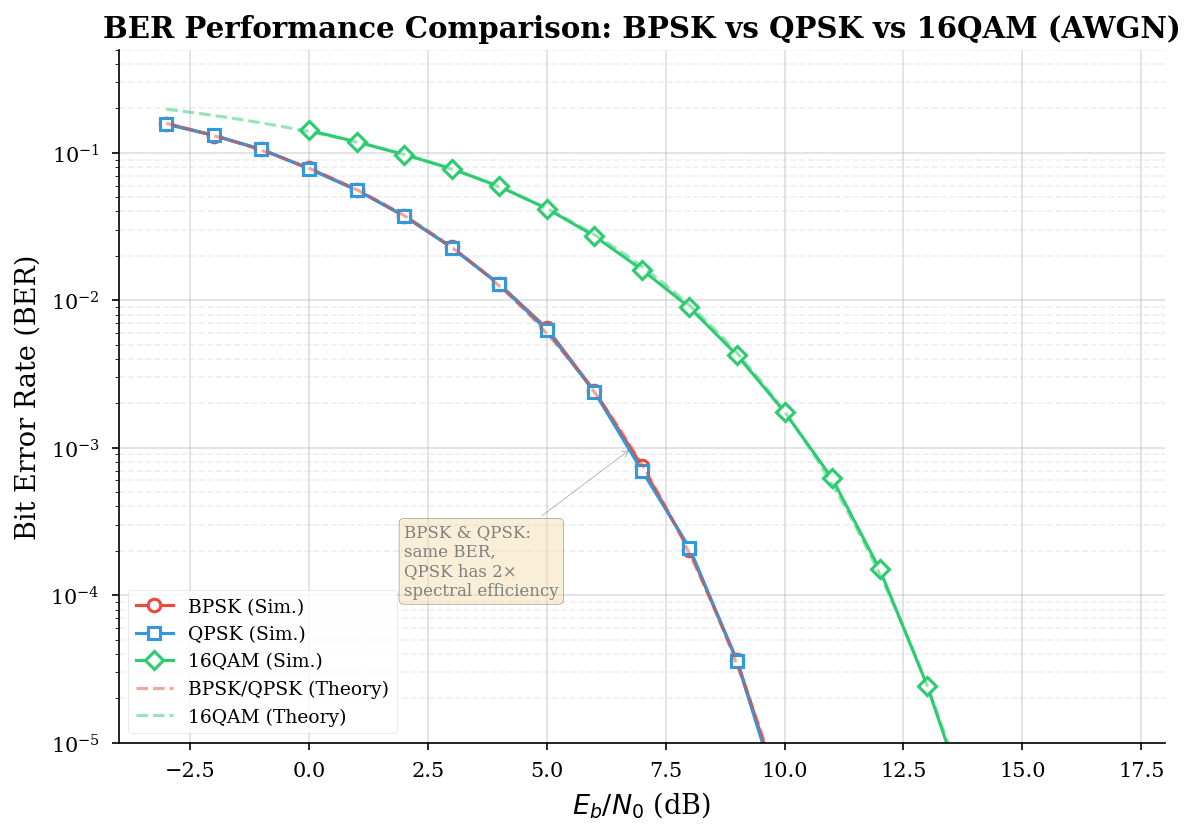

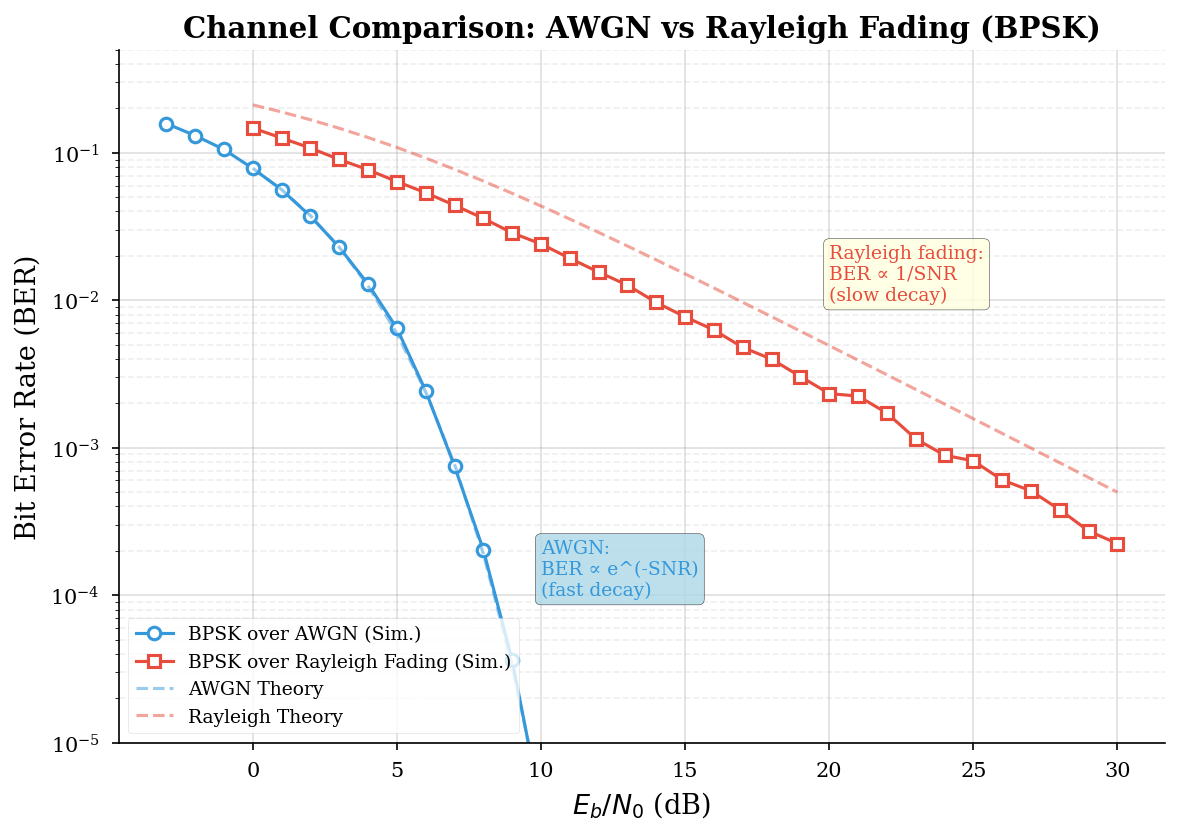

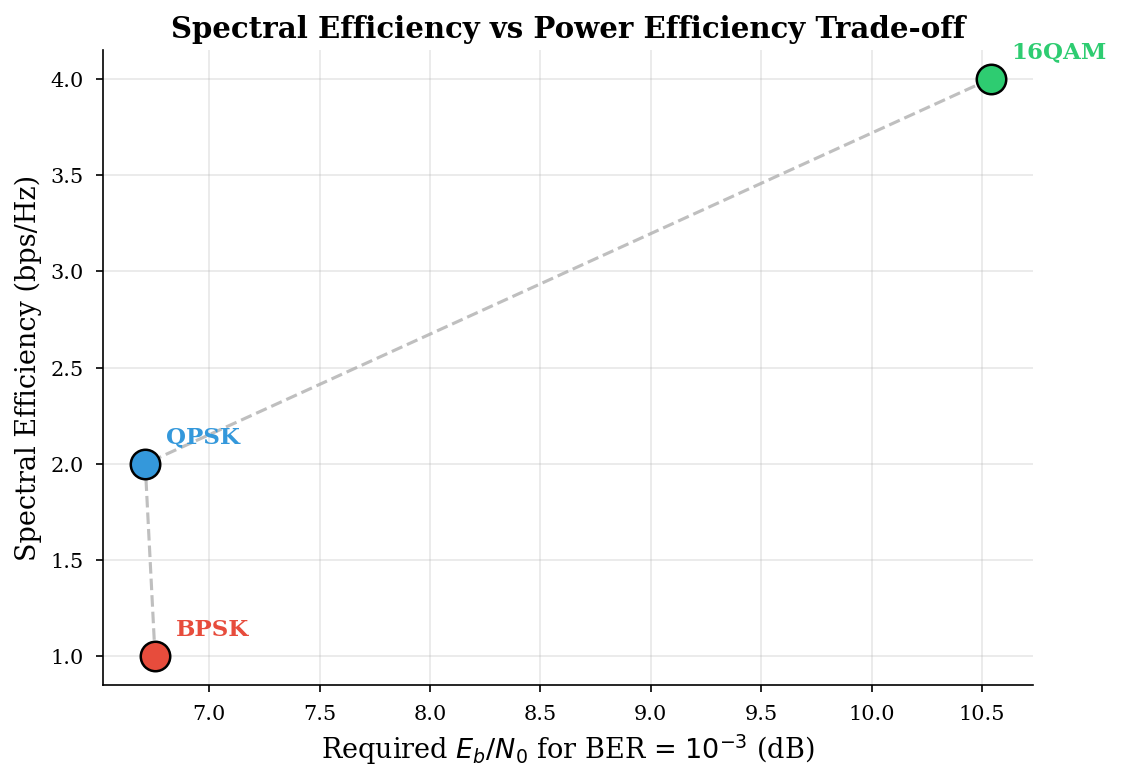

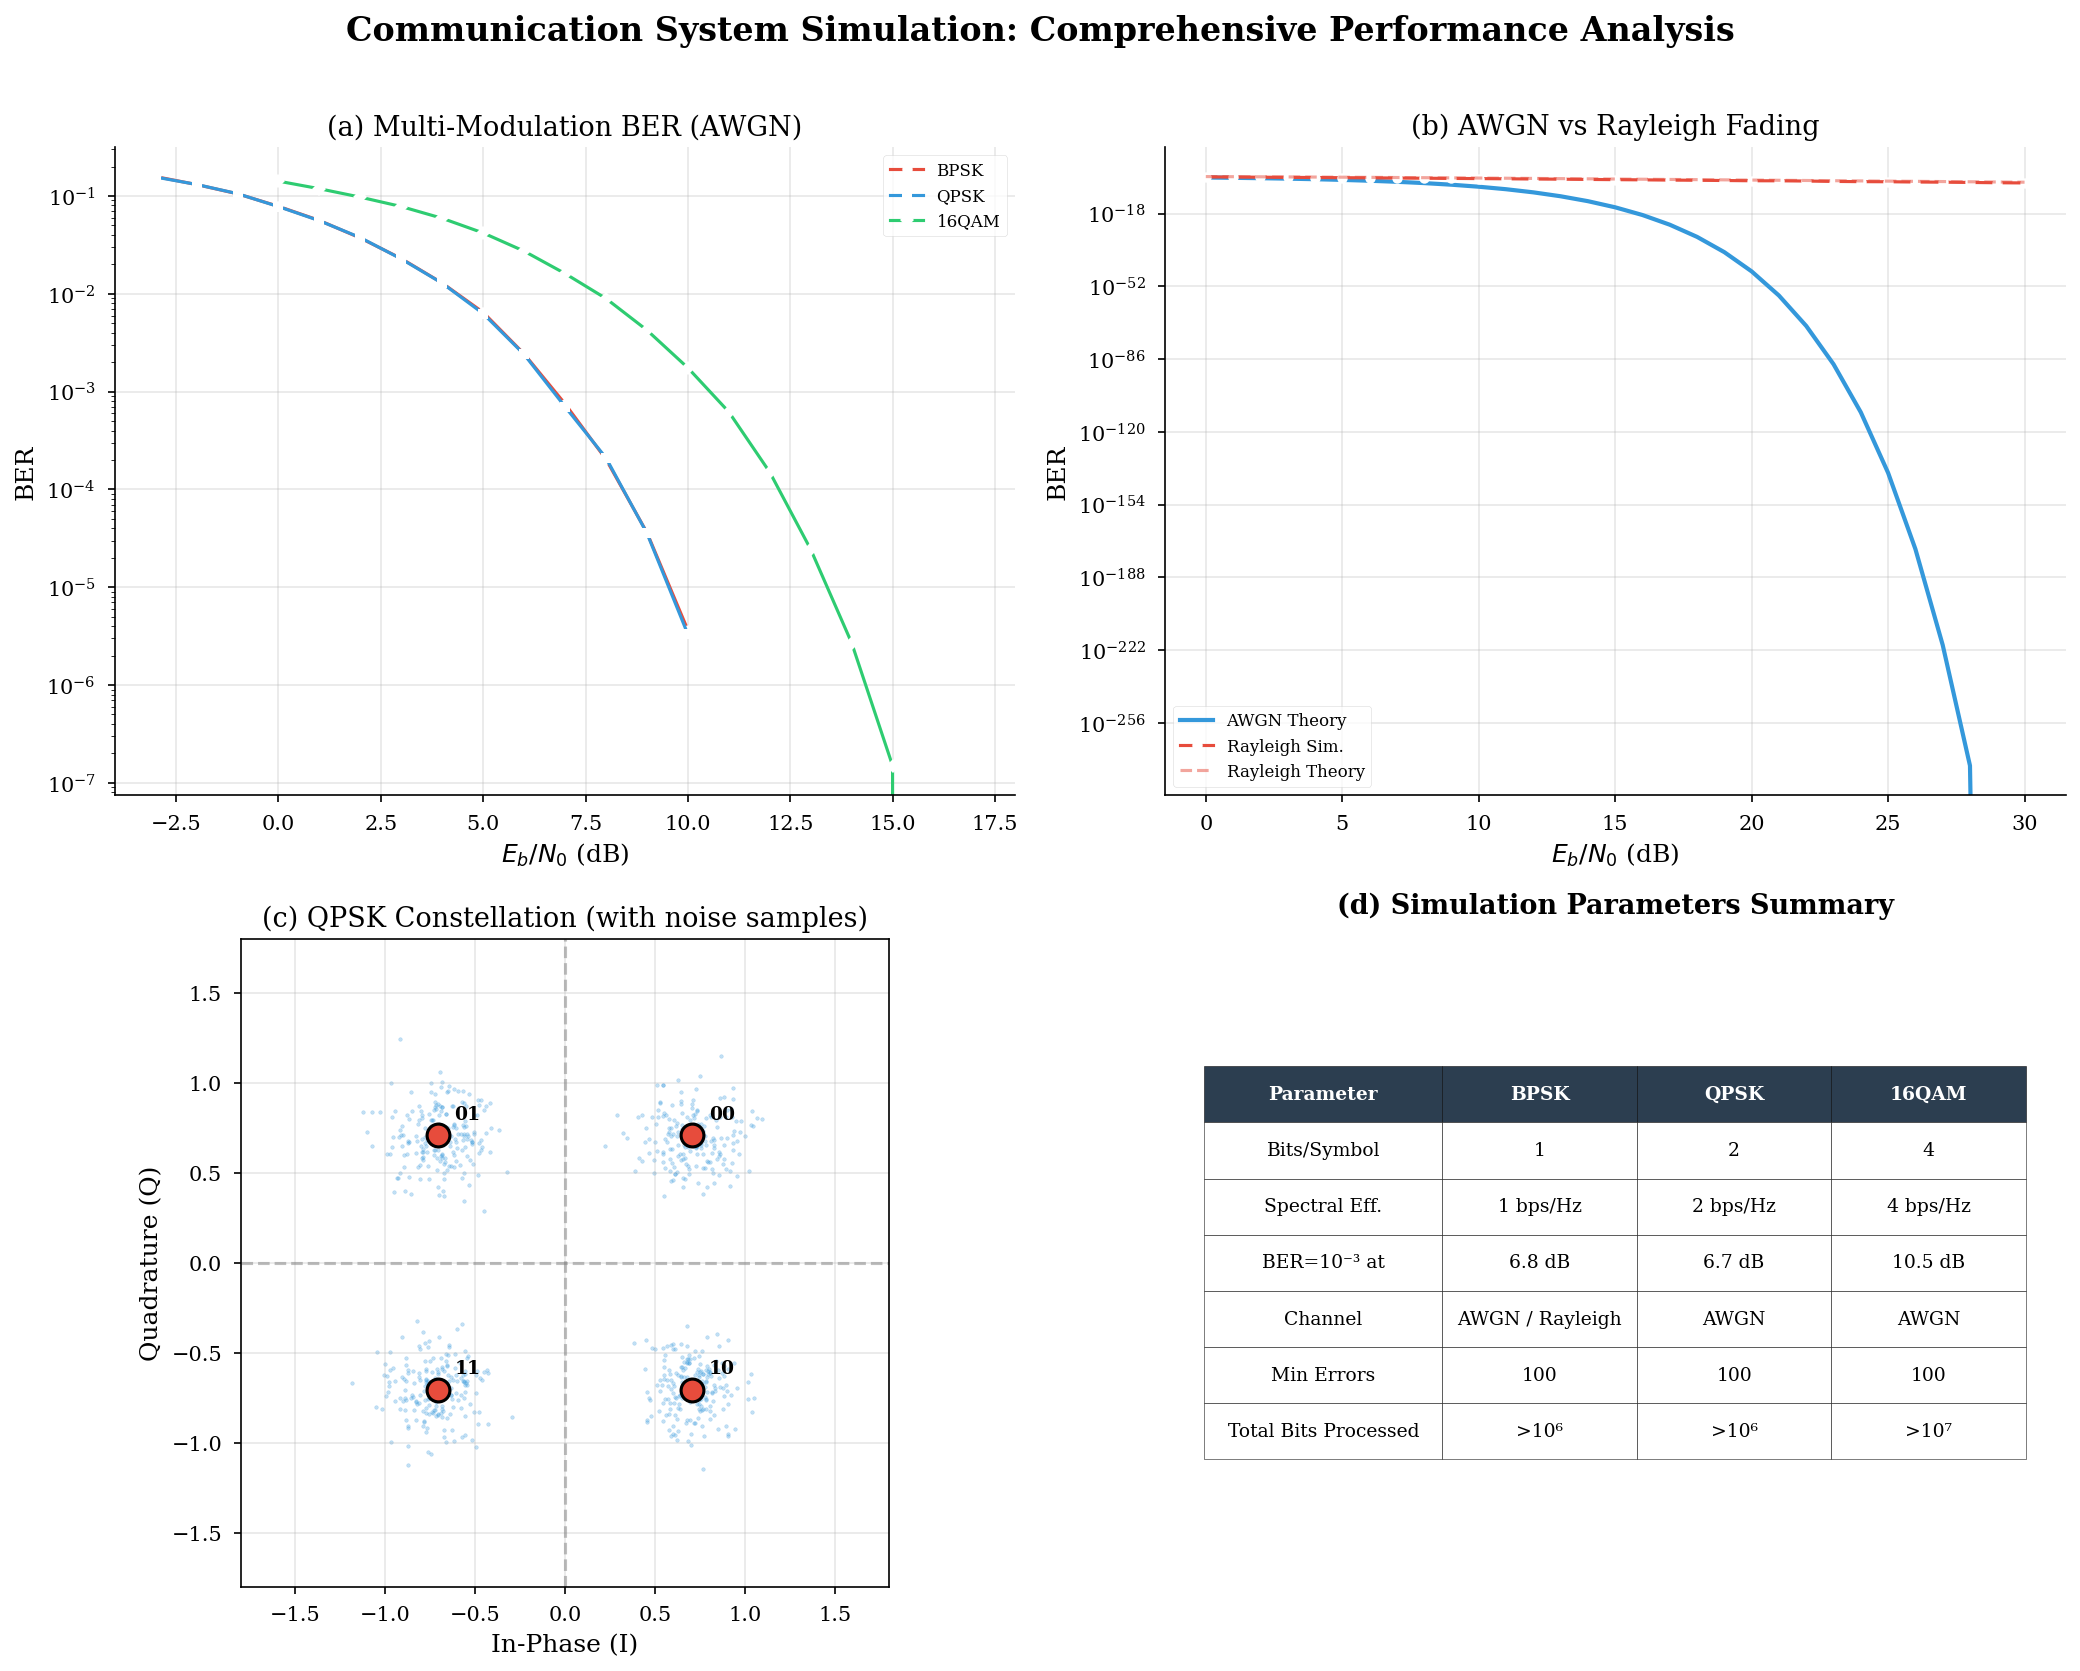

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erfc

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
})

df_bpsk = pd.read_csv('data/bpsk_ber_results.csv')
df_qpsk = pd.read_csv('data/qpsk_ber_results.csv')
df_16qam = pd.read_csv('data/16qam_ber_results.csv')
df_rayleigh = pd.read_csv('data/rayleigh_ber_results.csv')

figA, axA = plt.subplots(figsize=(9, 6))

axA.semilogy(df_bpsk['Eb_N0_dB'], df_bpsk['Simulated_BER'], 'o-',
             color='#E74C3C', markerfacecolor='white', markeredgewidth=1.5,
             label='BPSK (Sim.)')

axA.semilogy(df_qpsk['Eb_N0_dB'], df_qpsk['Simulated_BER'], 's-',
             color='#3498DB', markerfacecolor='white', markeredgewidth=1.5,
             label='QPSK (Sim.)')

axA.semilogy(df_16qam['Eb_N0_dB'], df_16qam['Simulated_BER'], 'D-',
             color='#2ECC71', markerfacecolor='white', markeredgewidth=1.5,
             label='16QAM (Sim.)')

Eb_N0_dense = np.linspace(-3, 17, 100)
Eb_N0_lin = 10**(Eb_N0_dense/10)
axA.semilogy(Eb_N0_dense, 0.5*erfc(np.sqrt(Eb_N0_lin)), '--',
             color='#E74C3C', alpha=0.5, label='BPSK/QPSK (Theory)')
axA.semilogy(Eb_N0_dense, (3/8)*erfc(np.sqrt(0.4*Eb_N0_lin)), '--',
             color='#2ECC71', alpha=0.5, label='16QAM (Theory)')

axA.set_xlabel('$E_b/N_0$ (dB)', fontsize=13)
axA.set_ylabel('Bit Error Rate (BER)', fontsize=13)
axA.set_title('BER Performance Comparison: BPSK vs QPSK vs 16QAM (AWGN)',
              fontweight='bold', fontsize=14)
axA.set_ylim(1e-5, 0.5)
axA.grid(True, which='major', alpha=0.4)
axA.grid(True, which='minor', linestyle='--', alpha=0.2)
axA.legend(loc='lower left', frameon=True, fancybox=True)
axA.spines['top'].set_visible(False)
axA.spines['right'].set_visible(False)

axA.annotate('BPSK & QPSK:\nsame BER,\nQPSK has 2×\nspectral efficiency',
             xy=(6.8, 1e-3), xytext=(2, 1e-4),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=8, color='gray', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

figA.savefig('figures/figA_multimod_BER_AWGN.pdf')
figA.savefig('figures/figA_multimod_BER_AWGN.png')
print("图A已保存")

figB, axB = plt.subplots(figsize=(9, 6))

axB.semilogy(df_bpsk['Eb_N0_dB'], df_bpsk['Simulated_BER'], 'o-',
             color='#3498DB', markerfacecolor='white', markeredgewidth=1.5,
             label='BPSK over AWGN (Sim.)')

axB.semilogy(df_rayleigh['Eb_N0_dB'], df_rayleigh['Simulated_BER_Rayleigh'], 's-',
             color='#E74C3C', markerfacecolor='white', markeredgewidth=1.5,
             label='BPSK over Rayleigh Fading (Sim.)')

axB.semilogy(df_rayleigh['Eb_N0_dB'], df_rayleigh['Theoretical_BER_AWGN'], '--',
             color='#3498DB', alpha=0.5, label='AWGN Theory')
axB.semilogy(df_rayleigh['Eb_N0_dB'], df_rayleigh['Theoretical_BER_Rayleigh'], '--',
             color='#E74C3C', alpha=0.5, label='Rayleigh Theory')

axB.set_xlabel('$E_b/N_0$ (dB)', fontsize=13)
axB.set_ylabel('Bit Error Rate (BER)', fontsize=13)
axB.set_title('Channel Comparison: AWGN vs Rayleigh Fading (BPSK)',
              fontweight='bold', fontsize=14)
axB.set_ylim(1e-5, 0.5)
axB.grid(True, which='major', alpha=0.4)
axB.grid(True, which='minor', linestyle='--', alpha=0.2)
axB.legend(loc='lower left', frameon=True, fancybox=True)
axB.spines['top'].set_visible(False)
axB.spines['right'].set_visible(False)

axB.annotate('Rayleigh fading:\nBER ∝ 1/SNR\n(slow decay)',
             xy=(20, 1e-2), fontsize=9, color='#E74C3C',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axB.annotate('AWGN:\nBER ∝ e^(-SNR)\n(fast decay)',
             xy=(10, 1e-4), fontsize=9, color='#3498DB',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

figB.savefig('figures/figB_channel_comparison.pdf')
figB.savefig('figures/figB_channel_comparison.png')
print("图B已保存")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erfc

df_bpsk = pd.read_csv('data/bpsk_ber_results.csv')
df_qpsk = pd.read_csv('data/qpsk_ber_results.csv')
df_16qam = pd.read_csv('data/16qam_ber_results.csv')

def find_required_snr(df, ber_col, target=1e-3):
    """找到达到目标BER所需的最小Eb/N0，找不到则返回NaN"""

    ber_values = pd.to_numeric(df[ber_col], errors='coerce')

    idx = (ber_values <= target)
    if idx.any():
        i = idx.idxmax()  
        if i == 0:
            return df['Eb_N0_dB'].iloc[i]
        x1, x2 = df['Eb_N0_dB'].iloc[i-1], df['Eb_N0_dB'].iloc[i]
        y1, y2 = ber_values.iloc[i-1], ber_values.iloc[i]

        if y1 <= 0 or y2 <= 0:
            return df['Eb_N0_dB'].iloc[i]
        log_target = np.log10(target)
        log_y1, log_y2 = np.log10(y1), np.log10(y2)
        t = (log_target - log_y1) / (log_y2 - log_y1)
        return x1 + t * (x2 - x1)
    else:
        print(f"警告：在 {ber_col} 中未达到 BER <= {target}，请扩展 SNR 范围")
        return float('nan') 

snr_bpsk = find_required_snr(df_bpsk, 'Simulated_BER')
snr_qpsk = find_required_snr(df_qpsk, 'Simulated_BER')
snr_16qam = find_required_snr(df_16qam, 'Simulated_BER')

print(f"Required SNR for BER=1e-3: BPSK={snr_bpsk:.2f}, QPSK={snr_qpsk:.2f}, 16QAM={snr_16qam:.2f}")

figC, axC = plt.subplots(figsize=(8, 5.5))
modulations = ['BPSK', 'QPSK', '16QAM']
spectral_eff = [1, 2, 4]
required_snr = [snr_bpsk, snr_qpsk, snr_16qam]
colors = ['#E74C3C', '#3498DB', '#2ECC71']

for i in range(3):
    if np.isnan(required_snr[i]):
        print(f"跳过 {modulations[i]}，因为缺少数据")
        continue
    axC.scatter(required_snr[i], spectral_eff[i], s=200, 
                c=colors[i], edgecolors='black', linewidth=1.2, zorder=5)
    axC.annotate(modulations[i], 
                 (required_snr[i], spectral_eff[i]),
                 textcoords="offset points", xytext=(10, 10),
                 fontsize=11, fontweight='bold', color=colors[i])

valid_idx = [i for i, v in enumerate(required_snr) if not np.isnan(v)]
if len(valid_idx) >= 2:
    valid_snr = [required_snr[i] for i in valid_idx]
    valid_se = [spectral_eff[i] for i in valid_idx]
    axC.plot(valid_snr, valid_se, '--', color='gray', alpha=0.5, zorder=1)

axC.set_xlabel('Required $E_b/N_0$ for BER = $10^{-3}$ (dB)', fontsize=13)
axC.set_ylabel('Spectral Efficiency (bps/Hz)', fontsize=13)
axC.set_title('Spectral Efficiency vs Power Efficiency Trade-off',
              fontweight='bold', fontsize=14)
axC.grid(True, alpha=0.3)
axC.spines['top'].set_visible(False)
axC.spines['right'].set_visible(False)

figC.savefig('figures/figC_spectral_efficiency.pdf')
figC.savefig('figures/figC_spectral_efficiency.png')
print("图C已保存")

figD, axes = plt.subplots(2, 2, figsize=(14, 11))

ax = axes[0, 0]
ax.semilogy(df_bpsk['Eb_N0_dB'], df_bpsk['Simulated_BER'], 'o-', color='#E74C3C',
            markerfacecolor='white', markersize=5, label='BPSK')
ax.semilogy(df_qpsk['Eb_N0_dB'], df_qpsk['Simulated_BER'], 's-', color='#3498DB',
            markerfacecolor='white', markersize=5, label='QPSK')
ax.semilogy(df_16qam['Eb_N0_dB'], df_16qam['Simulated_BER'], 'D-', color='#2ECC71',
            markerfacecolor='white', markersize=5, label='16QAM')
ax.set_xlabel('$E_b/N_0$ (dB)')
ax.set_ylabel('BER')
ax.set_title('(a) Multi-Modulation BER (AWGN)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[0, 1]
ax.semilogy(df_rayleigh['Eb_N0_dB'], df_rayleigh['Theoretical_BER_AWGN'], '-',
            color='#3498DB', linewidth=2, label='AWGN Theory')
ax.semilogy(df_rayleigh['Eb_N0_dB'], df_rayleigh['Simulated_BER_Rayleigh'], 'o-',
            color='#E74C3C', markerfacecolor='white', markersize=5, label='Rayleigh Sim.')
ax.semilogy(df_rayleigh['Eb_N0_dB'], df_rayleigh['Theoretical_BER_Rayleigh'], '--',
            color='#E74C3C', alpha=0.5, label='Rayleigh Theory')
ax.set_xlabel('$E_b/N_0$ (dB)')
ax.set_ylabel('BER')
ax.set_title('(b) AWGN vs Rayleigh Fading')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1, 0]

constellation_qpsk = np.array([1+1j, -1+1j, -1-1j, 1-1j]) / np.sqrt(2)

np.random.seed(123)
for c in constellation_qpsk:
    noise_samples = c + 0.15 * (np.random.randn(200) + 1j * np.random.randn(200))
    ax.scatter(np.real(noise_samples), np.imag(noise_samples), s=3, alpha=0.3, color='#3498DB')

ax.scatter(np.real(constellation_qpsk), np.imag(constellation_qpsk), 
           s=120, c='#E74C3C', marker='o', edgecolors='black', linewidth=1.5, zorder=5)

labels = ['00', '01', '11', '10']
for i, (c, label) in enumerate(zip(constellation_qpsk, labels)):
    ax.annotate(label, (np.real(c), np.imag(c)), textcoords="offset points", 
                xytext=(8, 8), fontsize=9, fontweight='bold')

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.set_xlabel('In-Phase (I)')
ax.set_ylabel('Quadrature (Q)')
ax.set_title('(c) QPSK Constellation (with noise samples)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.axis('off')
table_data = [
    ['Parameter', 'BPSK', 'QPSK', '16QAM'],
    ['Bits/Symbol', '1', '2', '4'],
    ['Spectral Eff.', '1 bps/Hz', '2 bps/Hz', '4 bps/Hz'],
    [f'BER=10⁻³ at', f'{snr_bpsk:.1f} dB', f'{snr_qpsk:.1f} dB', f'{snr_16qam:.1f} dB'],
    ['Channel', 'AWGN / Rayleigh', 'AWGN', 'AWGN'],
    ['Min Errors', '100', '100', '100'],
    ['Total Bits Processed', '>10⁶', '>10⁶', '>10⁷'],
]
table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                 colWidths=[0.22, 0.18, 0.18, 0.18])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2.0)

for j in range(4):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')
ax.set_title('(d) Simulation Parameters Summary', fontweight='bold', y=1.02)

figD.suptitle('Communication System Simulation: Comprehensive Performance Analysis',
              fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
figD.savefig('figures/figD_comprehensive_analysis.pdf')
figD.savefig('figures/figD_comprehensive_analysis.png')
print("图D已保存（综合4面板图）")

print("\n🎉 全部图表生成完成！")

In [9]:
import pandas as pd
df_qpsk = pd.read_csv('data/qpsk_ber_results.csv')
print(df_qpsk.head(10))
print("\n最小BER:", df_qpsk['Simulated_BER'].min())

   Eb_N0_dB  Simulated_BER  Theoretical_BER
0        -3        0.15610         0.158368
1        -2        0.13117         0.130644
2        -1        0.10562         0.103759
3         0        0.07787         0.078650
4         1        0.05587         0.056282
5         2        0.03751         0.037506
6         3        0.02271         0.022878
7         4        0.01282         0.012501
8         5        0.00627         0.005954
9         6        0.00240         0.002388

最小BER: 3.3e-06
